## 1. Setup

In [15]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 4))  # avoids the Windows core-count warning

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
import joblib

warnings.filterwarnings('ignore', category=FutureWarning)   # keep other warnings visible

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# ---------------- configuration ----------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH   = Path('../data/processed/nykaa_campaign_features.csv')
OUT_DATA    = Path('../data/processed/nykaa_campaign_segments.csv')
MODELS_DIR  = Path('../models')
REPORTS_DIR = Path('../reports')

K_RANGE        = range(2, 9)   # all k values evaluated
K_INTERPRETABLE = (3, 6)       # k is chosen inside this range (a 2-way split is not a useful segmentation)
K_OVERRIDE     = None          # set e.g. K_OVERRIDE = 4 to force a value after reviewing section 5
N_BOOTSTRAPS   = 10            # stability resamples per k
SIL_SAMPLE     = 10_000        # silhouette is O(n^2): evaluate on a fixed random sample
PLOT_SAMPLE    = 10_000

for d in (MODELS_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

In [17]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicate rows: {df.duplicated().sum():,}")
if 'Campaign_ID' in df.columns:
    print(f"Duplicate Campaign_IDs: {df['Campaign_ID'].duplicated().sum():,}")

KPI_DEFINITIONS = {
    'CTR':                       'Clicks / Impressions x 100',
    'Conversion_Rate':           'Conversions / Clicks x 100',
    'Lead_Rate':                 'Leads / Clicks x 100',
    'Lead_to_Conversion_Rate':   'Conversions / Leads x 100',
    'Overall_Funnel_Efficiency': 'Conversions / Impressions x 100',
    'CPC':                       'Spend / Clicks',
    'CPA':                       'Spend / Conversions',
    'ROAS':                      'Revenue / Spend',
}

def _ratio(num, den, scale=1.0):
    return num.div(den.where(den > 0)) * scale          # den <= 0 -> NaN (never inf)

def add_marketing_kpis(frame):
    """Add any standard KPI that is missing. Existing columns are never overwritten."""
    d = frame.copy()
    def has(*cols): return all(c in d.columns for c in cols)
    recipes = {
        'CTR':                       (('Clicks', 'Impressions'),     lambda: _ratio(d['Clicks'], d['Impressions'], 100)),
        'Conversion_Rate':           (('Conversions', 'Clicks'),     lambda: _ratio(d['Conversions'], d['Clicks'], 100)),
        'Lead_Rate':                 (('Leads', 'Clicks'),           lambda: _ratio(d['Leads'], d['Clicks'], 100)),
        'Lead_to_Conversion_Rate':   (('Conversions', 'Leads'),      lambda: _ratio(d['Conversions'], d['Leads'], 100)),
        'Overall_Funnel_Efficiency': (('Conversions', 'Impressions'),lambda: _ratio(d['Conversions'], d['Impressions'], 100)),
        'CPC':                       (('Spend', 'Clicks'),           lambda: _ratio(d['Spend'], d['Clicks'])),
        'CPA':                       (('Spend', 'Conversions'),      lambda: _ratio(d['Spend'], d['Conversions'])),
        'ROAS':                      (('Revenue', 'Spend'),          lambda: _ratio(d['Revenue'], d['Spend'])),
    }
    for kpi, (needs, fn) in recipes.items():
        if kpi not in d.columns and has(*needs):
            d[kpi] = fn()
    return d

df = add_marketing_kpis(df)
df = df.replace([np.inf, -np.inf], np.nan)

present = [k for k in KPI_DEFINITIONS if k in df.columns]
print("\nKPIs available:", present)
print("KPIs unavailable (raw inputs missing):", [k for k in KPI_DEFINITIONS if k not in df.columns])
df[present].describe().T.round(3)

Shape: 55,555 rows x 53 columns
Duplicate rows: 0
Duplicate Campaign_IDs: 0

KPIs available: ['CTR', 'Conversion_Rate', 'Lead_Rate', 'Lead_to_Conversion_Rate', 'Overall_Funnel_Efficiency', 'CPC', 'CPA', 'ROAS']
KPIs unavailable (raw inputs missing): []


,count,mean,std,min,25%,50%,75%,max
CTR,55555.0,8.509,3.762,1.998,5.259,8.508,11.798,14.999
Conversion_Rate,55555.0,21.972,8.773,5.961,15.264,20.475,27.785,47.743
Lead_Rate,55555.0,39.939,11.576,19.924,29.890,39.948,50.040,59.993
Lead_to_Conversion_Rate,55555.0,55.011,14.491,29.665,42.409,55.141,67.513,79.987
Overall_Funnel_Efficiency,55555.0,1.873,1.167,0.136,0.965,1.621,2.518,7.077
CPC,55555.0,69.377,85.813,3.539,22.962,41.494,81.454,1341.072
CPA,55555.0,377.347,541.085,9.080,105.435,207.510,428.580,15473.160
ROAS,55555.0,3.714,4.493,0.033,1.041,2.240,4.626,75.441


## 3. Feature selection
The brief's segments are defined along two behavioural axes, so features are grouped that way:

* **Engagement axis:** `Engagement_Score`, `CTR`
* **Conversion axis:** `Conversion_Rate`, `Lead_to_Conversion_Rate`, `Lead_Rate`, `Overall_Funnel_Efficiency`

The funnel ratios are mathematically linked (e.g. conversion rate = lead rate × lead-to-conversion rate), so left alone they would count the same signal several times in K-Means. Redundant features are pruned iteratively: for the most correlated pair, drop the member that is more correlated with everything else. `Engagement_Score` and `Conversion_Rate` are **protected** because the segment definitions depend on them. This replaces the earlier column-order-dependent filter, which dropped `Engagement_Score` by position.

Candidates: ['Engagement_Score', 'CTR', 'Conversion_Rate', 'Lead_Rate']


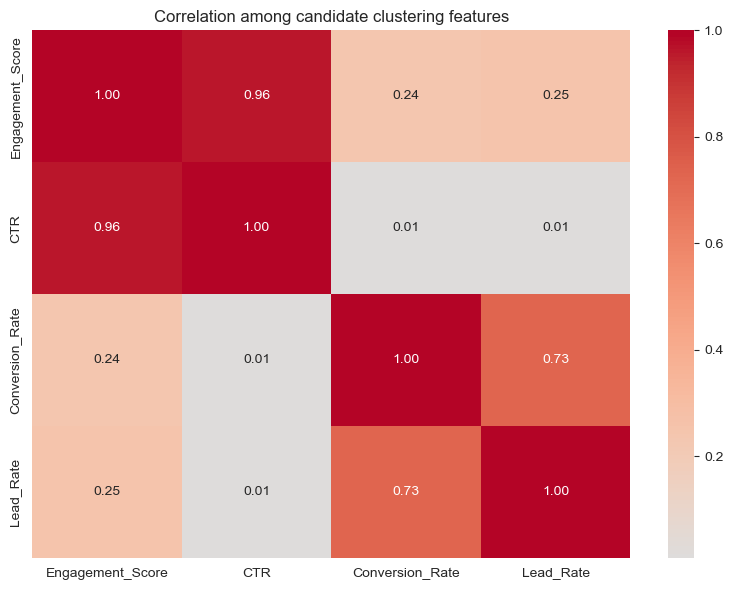


Dropped as redundant (dropped, kept-instead, |r|):
   ('CTR', 'Engagement_Score', 0.961)

Final clustering features: ['Engagement_Score', 'Conversion_Rate', 'Lead_Rate']


In [48]:
ENENGAGEMENT_FEATURES = [
    c for c in ['Engagement_Score', 'CTR']
    if c in df.columns
]

CONVERSION_FEATURES = [
    c for c in ['Conversion_Rate', 'Lead_Rate']
    if c in df.columns
]

PROTECTED = [
    c for c in ['Engagement_Score', 'Conversion_Rate']
    if c in df.columns
]
candidates = ENGAGEMENT_FEATURES + CONVERSION_FEATURES

assert ENGAGEMENT_FEATURES and CONVERSION_FEATURES, "Need at least one engagement and one conversion feature."
print("Candidates:", candidates)

plt.figure(figsize=(8, 6))
sns.heatmap(df[candidates].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation among candidate clustering features')
plt.tight_layout(); plt.show()

def prune_correlated(frame, protected, threshold=0.85):
    cols, log = list(frame.columns), []
    while len(cols) > 2:
        corr = frame[cols].corr().abs().to_numpy(copy=True)
        np.fill_diagonal(corr, 0.0)
        for a in protected:                              # pairs of two protected features are left alone
            for b in protected:
                if a in cols and b in cols:
                    corr[cols.index(a), cols.index(b)] = 0.0
        if corr.max() <= threshold:
            break
        i, j = np.unravel_index(corr.argmax(), corr.shape)
        a, b, r = cols[i], cols[j], corr[i, j]
        if a in protected:   drop, keep = b, a
        elif b in protected: drop, keep = a, b
        else:
            full = frame[cols].corr().abs().to_numpy(copy=True); np.fill_diagonal(full, 0.0)
            drop, keep = (a, b) if full[i].mean() >= full[j].mean() else (b, a)
        log.append((drop, keep, round(float(r), 3)))
        cols.remove(drop)
    return cols, log

cluster_features, dropped_log = prune_correlated(df[candidates], PROTECTED, threshold=0.85)

print("\nDropped as redundant (dropped, kept-instead, |r|):")
for item in dropped_log: print("  ", item)
print("\nFinal clustering features:", cluster_features)
assert any(c in cluster_features for c in ENGAGEMENT_FEATURES) and any(c in cluster_features for c in CONVERSION_FEATURES)

,skewness,missing
Engagement_Score,0.16,0
Conversion_Rate,0.56,0
Lead_Rate,0.00,0


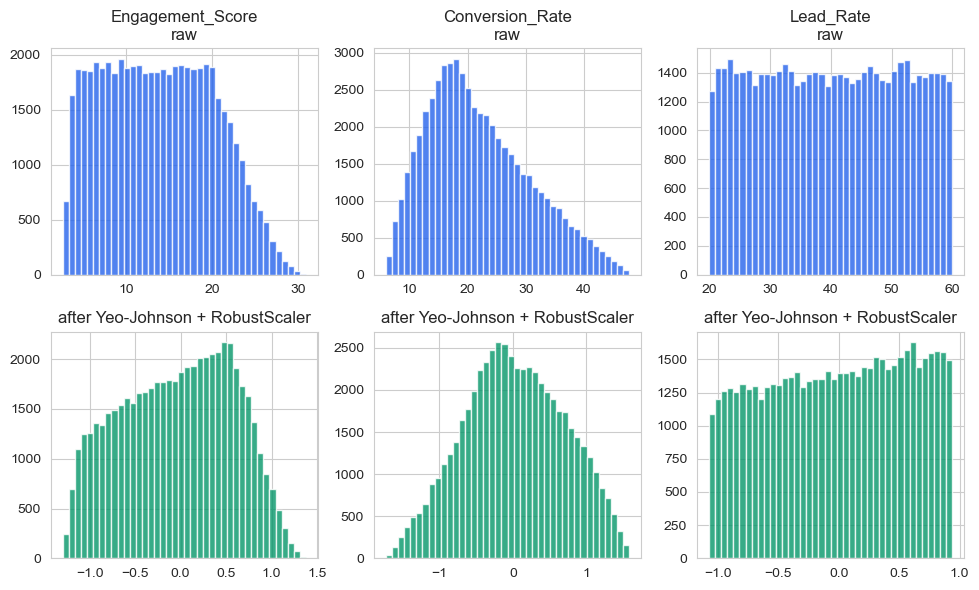

Model matrix: (55555, 3)
Scaling: RobustScaler


In [49]:


skew = df[cluster_features].skew().round(2).rename('skewness')
missing = df[cluster_features].isna().sum().rename('missing')

display(pd.concat([skew, missing], axis=1))


# Visualize distributions
fig, axes = plt.subplots(
    2,
    len(cluster_features),
    figsize=(3.3 * len(cluster_features), 6)
)

axes = np.atleast_2d(axes)


# Preview transformation
preview = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('transform', PowerTransformer(
        method='yeo-johnson',
        standardize=False
    )),
    ('scale', RobustScaler())
])

Xp = pd.DataFrame(
    preview.fit_transform(df[cluster_features]),
    columns=cluster_features
)


for i, c in enumerate(cluster_features):

    axes[0, i].hist(
        df[c].dropna(),
        bins=40,
        color='#2563eb',
        alpha=.8
    )
    axes[0, i].set_title(f'{c}\nraw')

    axes[1, i].hist(
        Xp[c],
        bins=40,
        color='#059669',
        alpha=.8
    )
    axes[1, i].set_title(
        'after Yeo-Johnson + RobustScaler'
    )


plt.tight_layout()
plt.show()


# ============================================================
# FINAL PREPROCESSING PIPELINE
# ============================================================

def make_preprocessor():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('transform', PowerTransformer(
            method='yeo-johnson',
            standardize=False
        )),
        ('scale', RobustScaler())
    ])


preprocessor = make_preprocessor()

X = preprocessor.fit_transform(
    df[cluster_features]
)

print("Model matrix:", X.shape)
print("Scaling: RobustScaler")

In [51]:
rng = np.random.RandomState(RANDOM_STATE)
rows = []
for k in K_RANGE:
    ref = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    lab = ref.labels_
    aris = []
    for b in range(N_BOOTSTRAPS):
        idx = rng.choice(len(X), size=int(0.8 * len(X)), replace=False)
        boot = KMeans(n_clusters=k, n_init=3, random_state=RANDOM_STATE + b + 1).fit(X[idx])
        aris.append(adjusted_rand_score(lab, boot.predict(X)))
    rows.append({
        'k': k,
        'inertia': ref.inertia_,
        'silhouette': silhouette_score(X, lab, sample_size=min(SIL_SAMPLE, len(X)), random_state=RANDOM_STATE),
        'davies_bouldin': davies_bouldin_score(X, lab),
        'calinski_harabasz': calinski_harabasz_score(X, lab),
        'stability_ARI': float(np.mean(aris)),
    })
k_table = pd.DataFrame(rows).set_index('k')

lo, hi = K_INTERPRETABLE
window = k_table.loc[lo:hi].copy()
window['rank'] = (window['silhouette'].rank(ascending=False)
                  + window['davies_bouldin'].rank(ascending=True)
                  + window['stability_ARI'].rank(ascending=False)) / 3
k_table['mean_rank_(in range)'] = window['rank']

best_k_by_rank = int(window['rank'].idxmin())
optimal_k = int(K_OVERRIDE) if K_OVERRIDE else best_k_by_rank

display(k_table.round(4))
print(f"Best silhouette overall: k={int(k_table['silhouette'].idxmax())}")
print(f"Chosen k (best mean rank within {lo}-{hi}): {best_k_by_rank}" + (f"   -> overridden to {optimal_k}" if K_OVERRIDE else ""))

,inertia,silhouette,davies_bouldin,calinski_harabasz,stability_ARI,mean_rank_(in range)
k,,,,,,
2,36288.3448,0.3708,1.0554,44387.2262,0.9957,NaN
3,27310.4807,0.3398,1.0758,38619.8410,0.9892,1.6667
4,21780.6532,0.3130,1.0970,36984.0966,0.9390,3.3333
5,18282.1319,0.2986,1.0603,35703.1048,0.9741,2.6667
6,15921.5795,0.2912,1.0488,34443.8009,0.9870,2.3333
7,14398.1357,0.2886,1.0860,32719.3166,0.8447,NaN
8,13239.4106,0.2763,1.1272,31193.6794,0.8255,NaN


Best silhouette overall: k=2
Chosen k (best mean rank within 3-6): 3


“Among the interpretable range of k=3–6, k=3 achieved the best combined ranking across Silhouette Score, Davies-Bouldin Score, and cluster stability. Therefore, k=3 was selected for the final audience segmentation model.”

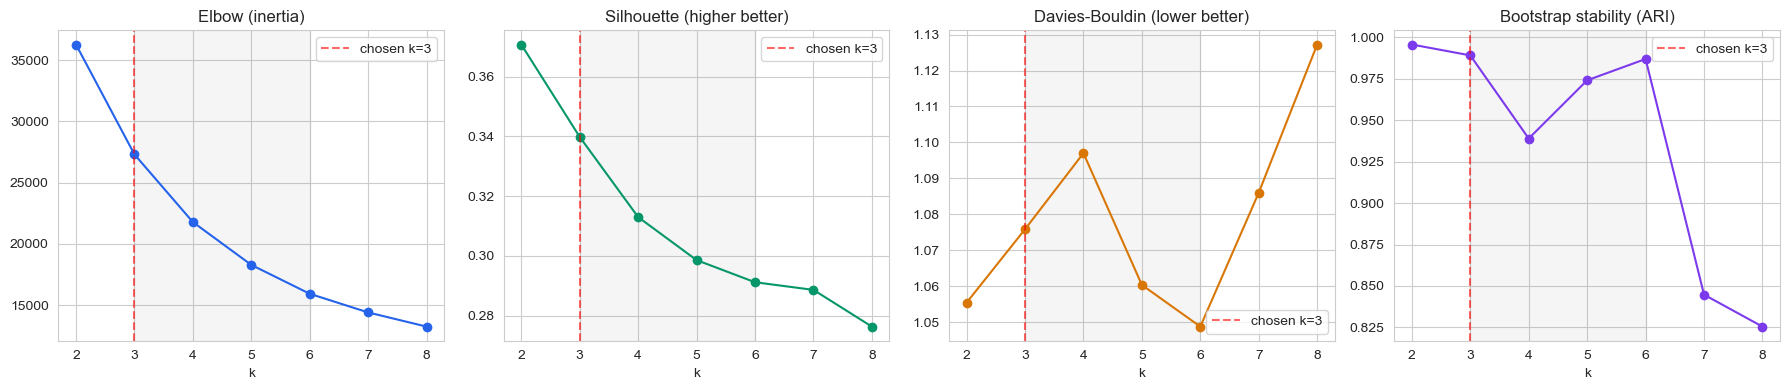

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
panels = [('inertia', 'Elbow (inertia)', '#2563eb'), ('silhouette', 'Silhouette (higher better)', '#059669'),
          ('davies_bouldin', 'Davies-Bouldin (lower better)', '#d97706'), ('stability_ARI', 'Bootstrap stability (ARI)', '#7c3aed')]
for ax, (col, title, colour) in zip(axes, panels):
    ax.plot(k_table.index, k_table[col], marker='o', color=colour)
    ax.axvline(optimal_k, color='r', ls='--', alpha=.6, label=f'chosen k={optimal_k}')
    ax.axvspan(lo, hi, color='grey', alpha=.08)
    ax.set_title(title); ax.set_xlabel('k'); ax.legend()
plt.tight_layout(); plt.show()

In [53]:
seg_pipeline = Pipeline(make_preprocessor().steps +
                        [('kmeans', KMeans(n_clusters=optimal_k, n_init=20, random_state=RANDOM_STATE))])
seg_pipeline.fit(df[cluster_features])

X = seg_pipeline[:-1].transform(df[cluster_features])
df['Cluster'] = seg_pipeline.predict(df[cluster_features])

sil_final = silhouette_score(X, df['Cluster'], sample_size=min(SIL_SAMPLE, len(X)), random_state=RANDOM_STATE)
db_final  = davies_bouldin_score(X, df['Cluster'])
print(f"k = {optimal_k}")
print(f"Silhouette (sample of {min(SIL_SAMPLE, len(X)):,}): {sil_final:.4f}")
print(f"Davies-Bouldin: {db_final:.4f}")
print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index().to_string())

if sil_final < 0.25:
    print("\nNOTE: silhouette < 0.25 means the clusters overlap heavily. Treat segments as useful partitions of a "
          "continuum rather than naturally separated groups, and rely on the validation in section 8.")

k = 3
Silhouette (sample of 10,000): 0.3398
Davies-Bouldin: 1.0759

Cluster sizes:
Cluster
0    18608
1    22544
2    14403


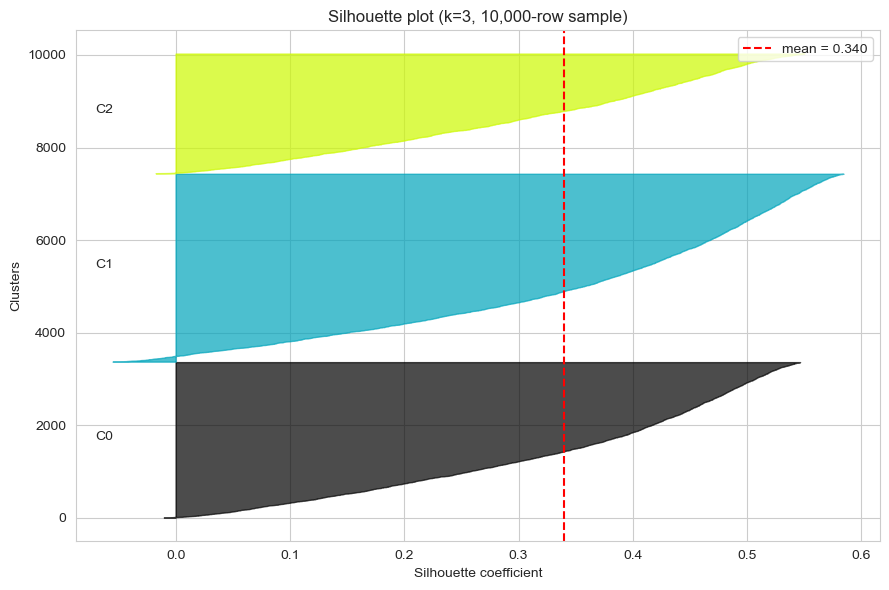

In [54]:
# Per-sample silhouette plot on a fixed subsample (full silhouette_samples on all rows is slow and memory-heavy)
idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=min(PLOT_SAMPLE, len(X)), replace=False)
sv = silhouette_samples(X[idx], df['Cluster'].to_numpy()[idx])
lab_s = df['Cluster'].to_numpy()[idx]

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for i in range(optimal_k):
    vals = np.sort(sv[lab_s == i])
    y_upper = y_lower + len(vals)
    colour = plt.cm.nipy_spectral(i / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=colour, edgecolor=colour, alpha=.7)
    ax.text(-0.07, y_lower + .5 * len(vals), f'C{i}')
    y_lower = y_upper + 10
ax.axvline(sv.mean(), color='red', ls='--', label=f'mean = {sv.mean():.3f}')
ax.set_xlabel('Silhouette coefficient'); ax.set_ylabel('Clusters')
ax.set_title(f'Silhouette plot (k={optimal_k}, {len(idx):,}-row sample)'); ax.legend()
plt.tight_layout(); plt.show()

Cluster profile (original units, mean):


,Engagement_Score,Conversion_Rate,Lead_Rate,CTR,ROI,ROAS,Revenue,Spend,Acquisition_Cost,CPA,CPC,Impressions,Clicks,Leads,Conversions,Duration,Count,Share_%
Cluster,,,,,,,,,,,,,,,,,,
0,20.147,27.721,48.027,11.502,5.284,6.284,872588.191,173955.530,152.227,152.227,39.762,55310.768,6358.204,3034.423,1745.677,17.399,18608,33.49
1,12.006,14.268,28.843,8.393,1.342,2.342,326216.317,175499.957,529.264,529.264,69.747,54858.174,4606.841,1327.718,656.086,17.479,22544,40.58
2,8.346,26.601,46.857,4.822,1.541,2.541,351664.415,173969.960,430.407,430.407,107.060,55159.482,2657.480,1242.462,701.699,17.456,14403,25.93


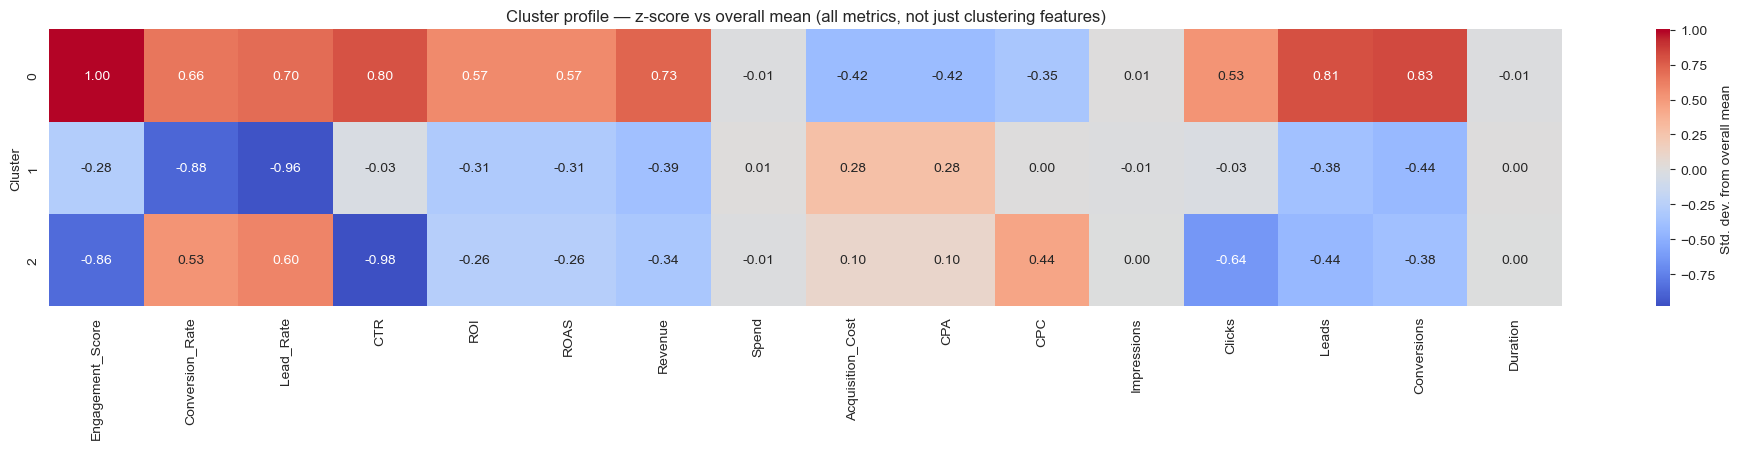

In [55]:
PROFILE_COLS = [c for c in dict.fromkeys(
    cluster_features + ENGAGEMENT_FEATURES + CONVERSION_FEATURES +
    ['ROI', 'ROAS', 'Revenue', 'Spend', 'Acquisition_Cost', 'CPA', 'CPC',
     'Impressions', 'Clicks', 'Leads', 'Conversions', 'Duration']) if c in df.columns]

profile = df.groupby('Cluster')[PROFILE_COLS].mean()
profile['Count'] = df['Cluster'].value_counts().sort_index()
profile['Share_%'] = (profile['Count'] / len(df) * 100).round(2)
print("Cluster profile (original units, mean):")
display(profile.round(3))

mu, sd = df[PROFILE_COLS].mean(), df[PROFILE_COLS].std()
z = (profile[PROFILE_COLS] - mu) / sd

plt.figure(figsize=(1.1 * len(PROFILE_COLS) + 2, 0.7 * optimal_k + 2.5))
sns.heatmap(z, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Std. dev. from overall mean'})
plt.title('Cluster profile — z-score vs overall mean (all metrics, not just clustering features)')
plt.tight_layout(); plt.show()

In [68]:


# Features used to calculate engagement and conversion indices
ENG_NAMING = [
    c for c in ['Engagement_Score', 'CTR']
    if c in df.columns
]

CONV_NAMING = [
    c for c in ['Conversion_Rate', 'Lead_Rate']
    if c in df.columns
]

assert ENG_NAMING and CONV_NAMING, \
    "Naming needs at least one engagement and one conversion metric in the data."


eng_idx = z[ENG_NAMING].mean(axis=1)
conv_idx = z[CONV_NAMING].mean(axis=1)

THRESH = 0.25


def name_segment(eng, conv, t=THRESH):
    if eng > t and conv > t:
        return 'Highly Engaged Audience'

    if conv > t:
        return 'High Conversion Audience'

    if eng < -t and conv <= t:
        return 'Low Engagement Audience'

    return 'Potential Customers'


base_names = pd.Series({
    c: name_segment(eng_idx[c], conv_idx[c])
    for c in z.index
})



cluster_to_segment = {}

for base, grp in base_names.groupby(base_names):

    if len(grp) == 1:
        cluster_to_segment[int(grp.index[0])] = base

    else:
        for c in grp.index:
            cluster_to_segment[int(c)] = f"{base} (C{c})"


SEGMENT_ACTIONS = {
    'Highly Engaged Audience':
        'Scale budget and use as lookalike seed; monitor frequency to avoid ad fatigue.',

    'High Conversion Audience':
        'Efficient converters: raise spend where CPA/ROAS hold up; test stronger creatives to lift engagement.',

    'Low Engagement Audience':
        'Refresh creative and targeting, or cut spend; re-test on a small budget before scaling.',

    'Potential Customers':
        'Nurture with retargeting and offers; A/B test messaging to push them toward conversion.'
}


def action_for(name):
    return SEGMENT_ACTIONS.get(
        name.split(' (C')[0],
        ''
    )



df['Segment_Name'] = df['Cluster'].map(cluster_to_segment)




profile['Engagement_Index'] = eng_idx.round(2)
profile['Conversion_Index'] = conv_idx.round(2)
profile['Segment_Name'] = profile.index.map(cluster_to_segment)



summary = profile[
    [
        'Segment_Name',
        'Count',
        'Share_%',
        'Engagement_Index',
        'Conversion_Index'
    ]
].copy()

summary['Recommended_Action'] = summary['Segment_Name'].map(action_for)



display(
    summary.style.set_properties(
        subset=['Recommended_Action'],
        **{
            'text-align': 'left',
            'white-space': 'normal'
        }
    )
)

,Segment_Name,Count,Share_%,Engagement_Index,Conversion_Index,Recommended_Action
Cluster,,,,,,
0,Highly Engaged Audience,18608,33.490000,0.900000,0.680000,Scale budget and use as lookalike seed; monitor frequency to avoid ad fatigue.
1,Potential Customers,22544,40.580000,-0.160000,-0.920000,Nurture with retargeting and offers; A/B test messaging to push them toward conversion.
2,High Conversion Audience,14403,25.930000,-0.920000,0.560000,Efficient converters: raise spend where CPA/ROAS hold up; test stronger creatives to lift engagement.


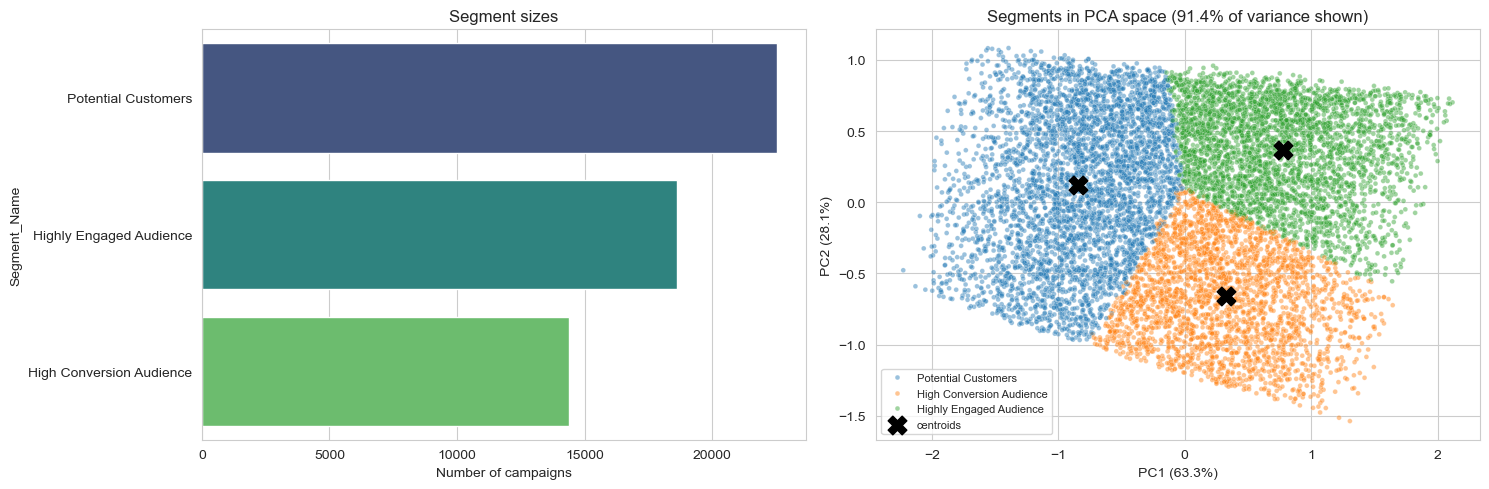

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df['Segment_Name'].value_counts()
sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_xlabel('Number of campaigns'); axes[0].set_title('Segment sizes')

sub = np.random.RandomState(RANDOM_STATE).choice(len(X), size=min(PLOT_SAMPLE, len(X)), replace=False)
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
P = pca.transform(X[sub])
sns.scatterplot(x=P[:, 0], y=P[:, 1], hue=df['Segment_Name'].to_numpy()[sub], s=12, alpha=.45, ax=axes[1])
C = pca.transform(seg_pipeline['kmeans'].cluster_centers_)
axes[1].scatter(C[:, 0], C[:, 1], marker='X', s=180, c='black', label='centroids')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title(f'Segments in PCA space ({pca.explained_variance_ratio_[:2].sum()*100:.1f}% of variance shown)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

,H,p_value,epsilon_sq
metric,,,
ROI,11584.4948,0.0000,0.2085
ROAS,11584.5986,0.0000,0.2085
Revenue,14602.5951,0.0000,0.2628
Spend,6.0984,0.0474,0.0001
Acquisition_Cost,13365.1234,0.0000,0.2406
CPA,13365.1273,0.0000,0.2406


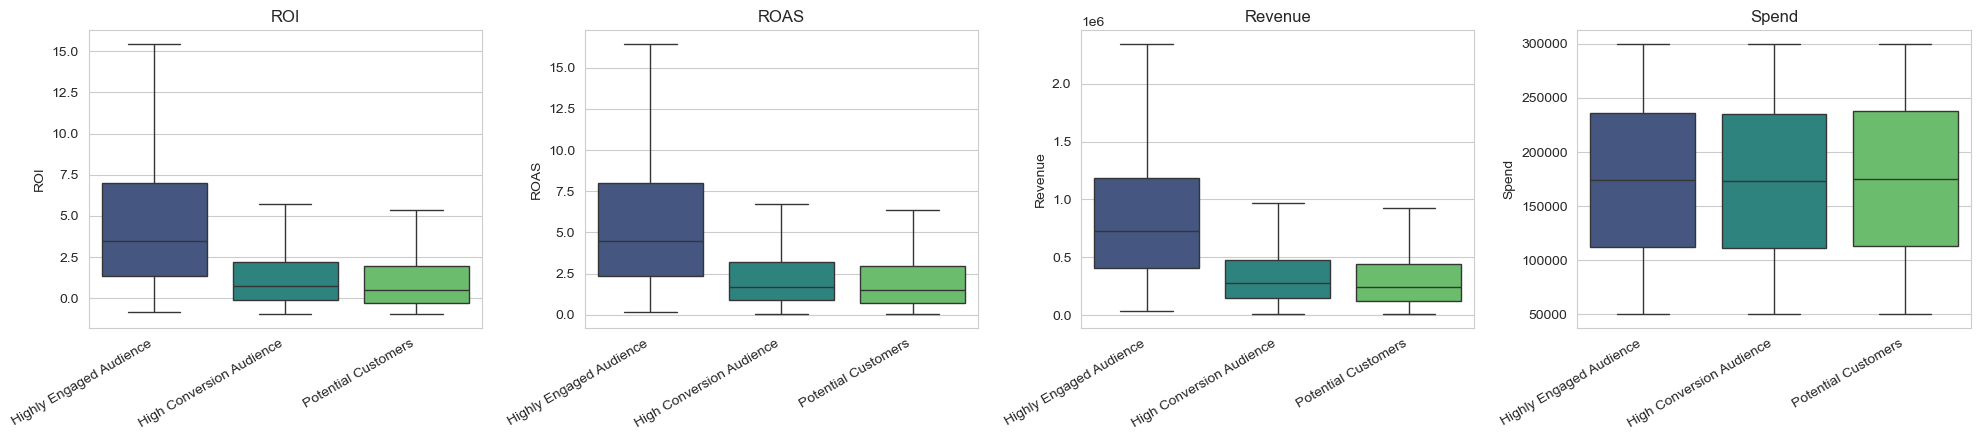

In [72]:
OUTCOMES = [c for c in ['ROI', 'ROAS', 'Revenue', 'Spend', 'Acquisition_Cost', 'CPA'] if c in df.columns]
res = []
for col in OUTCOMES:
    groups = [g[col].dropna().to_numpy() for _, g in df.groupby('Segment_Name')]
    H, p = stats.kruskal(*groups)
    n, k = sum(len(g) for g in groups), len(groups)
    res.append({'metric': col, 'H': H, 'p_value': p, 'epsilon_sq': max(0.0, (H - k + 1) / (n - k))})
outcome_tests = pd.DataFrame(res).set_index('metric')
display(outcome_tests.round(4))

if OUTCOMES:
    show = OUTCOMES[:4]
    fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 4.5))
    axes = np.atleast_1d(axes)
    order = df.groupby('Segment_Name')[show[0]].median().sort_values(ascending=False).index
    for ax, col in zip(axes, show):
        sns.boxplot(data=df, x='Segment_Name', y=col, order=order, showfliers=False, hue='Segment_Name',
                    palette='viridis', legend=False, ax=ax)
        ax.set_title(col); ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        for t in ax.get_xticklabels(): t.set_ha('right')
    plt.tight_layout(); plt.show()

In [73]:
def onehot_groups(frame, prefixes):
    out = {}
    for p in prefixes:
        cols = [c for c in frame.columns if c.startswith(p)]
        cols = [c for c in cols if set(frame[c].dropna().unique()) <= {0, 1, True, False}]
        if len(cols) >= 2:
            out[p] = cols
    return out

groups = onehot_groups(df, ['Customer_Segment_', 'Channel_Used_', 'Channel_', 'Campaign_Type_', 'Target_Audience_'])
if not groups:
    print("No one-hot audience/channel attributes found - skipping cross-check.")

for prefix, cols in groups.items():
    flags = df[cols].astype(int)
    labels = [c.replace(prefix, '') for c in cols]
    if (flags.sum(axis=1) == 1).mean() > 0.99:          # mutually exclusive -> categorical variable
        cat = flags.idxmax(axis=1).str.replace(prefix, '', regex=False)
        ct = pd.crosstab(df['Segment_Name'], cat)
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        cramers_v = np.sqrt(chi2 / (ct.to_numpy().sum() * (min(ct.shape) - 1)))
        print(f"\n{prefix.rstrip('_')}: row-% of each segment (chi2 p={p:.3g}, Cramer's V={cramers_v:.3f}; V<0.1 = essentially independent)")
        display((pd.crosstab(df['Segment_Name'], cat, normalize='index') * 100).round(1))
    else:                                                  # multi-label (e.g. several channels per campaign)
        print(f"\n{prefix.rstrip('_')}: share of campaigns in each segment using each option (%)")
        usage = flags.groupby(df['Segment_Name']).mean() * 100
        usage.columns = labels
        display(usage.round(1))


Customer_Segment: share of campaigns in each segment using each option (%)


,Premium Shoppers,Tier 2 City Customers,Working Women,Youth
Segment_Name,,,,
High Conversion Audience,20.4,19.7,19.4,19.6
Highly Engaged Audience,20.0,19.6,20.4,19.9
Potential Customers,19.6,20.0,20.1,20.3



Channel: share of campaigns in each segment using each option (%)


,Email,Facebook,Google,Instagram,WhatsApp,YouTube
Segment_Name,,,,,,
High Conversion Audience,17.0,16.8,16.9,16.5,16.2,16.2
Highly Engaged Audience,16.7,16.4,16.6,16.6,16.8,16.7
Potential Customers,16.8,16.8,16.4,16.4,16.5,16.6



Campaign_Type: share of campaigns in each segment using each option (%)


,Influencer,Paid Ads,SEO,Social Media
Segment_Name,,,,
High Conversion Audience,20.1,19.7,20.3,19.6
Highly Engaged Audience,20.3,19.6,19.6,20.4
Potential Customers,19.8,20.5,20.0,20.0



Target_Audience: share of campaigns in each segment using each option (%)


,Premium Shoppers,Tier 2 City Customers,Working Women,Youth
Segment_Name,,,,
High Conversion Audience,20.5,19.9,19.8,19.7
Highly Engaged Audience,20.2,19.9,20.1,19.9
Potential Customers,19.8,20.1,20.5,19.7


In [76]:
print(f"Model: K-Means, k={optimal_k}, on {len(cluster_features)} behavioural features {cluster_features}")
print(f"Quality: silhouette={sil_final:.3f}, Davies-Bouldin={db_final:.3f}, "
      f"bootstrap stability (ARI)={k_table.loc[optimal_k, 'stability_ARI']:.3f}\n")

for c in profile.sort_values('Share_%', ascending=False).index:
    r = profile.loc[c]
    line = (f"- {r['Segment_Name']} (cluster {c}, {r['Share_%']:.1f}% of campaigns): "
            f"engagement index {r['Engagement_Index']:+.2f}, conversion index {r['Conversion_Index']:+.2f}")
    extras = [f"{m} {r[m]:,.2f}" for m in ['ROI', 'ROAS', 'CPA'] if m in profile.columns]
    if extras: line += "; " + ", ".join(extras)
    print(line + f"\n    -> {action_for(r['Segment_Name'])}")

if len(outcome_tests):
    strong = outcome_tests[outcome_tests['epsilon_sq'] >= 0.06].index.tolist()
    weak = outcome_tests[outcome_tests['epsilon_sq'] < 0.01].index.tolist()
    print("\nOutcome validation:")
    print(f"  Segments differ materially (epsilon^2 >= 0.06) on: {strong or 'none'}")
    print(f"  Negligible difference (epsilon^2 < 0.01) on: {weak or 'none'}")

Model: K-Means, k=3, on 3 behavioural features ['Engagement_Score', 'Conversion_Rate', 'Lead_Rate']
Quality: silhouette=0.340, Davies-Bouldin=1.076, bootstrap stability (ARI)=0.989

- Potential Customers (cluster 1, 40.6% of campaigns): engagement index -0.16, conversion index -0.92; ROI 1.34, ROAS 2.34, CPA 529.26
    -> Nurture with retargeting and offers; A/B test messaging to push them toward conversion.
- Highly Engaged Audience (cluster 0, 33.5% of campaigns): engagement index +0.90, conversion index +0.68; ROI 5.28, ROAS 6.28, CPA 152.23
    -> Scale budget and use as lookalike seed; monitor frequency to avoid ad fatigue.
- High Conversion Audience (cluster 2, 25.9% of campaigns): engagement index -0.92, conversion index +0.56; ROI 1.54, ROAS 2.54, CPA 430.41
    -> Efficient converters: raise spend where CPA/ROAS hold up; test stronger creatives to lift engagement.

Outcome validation:
  Segments differ materially (epsilon^2 >= 0.06) on: ['ROI', 'ROAS', 'Revenue', 'Acquisition_

In [78]:
artifact = {
    'pipeline': seg_pipeline,
    'features': cluster_features,
    'cluster_to_segment': cluster_to_segment,
    'segment_actions': SEGMENT_ACTIONS,
    'kpi_definitions': KPI_DEFINITIONS,
    'k': optimal_k,
    'metrics': {'silhouette': float(sil_final), 'davies_bouldin': float(db_final),
                'stability_ARI': float(k_table.loc[optimal_k, 'stability_ARI'])},
    'random_state': RANDOM_STATE,
    'sklearn_version': sklearn.__version__,
}
joblib.dump(artifact, MODELS_DIR / 'audience_segmentation_artifact.joblib')

df.to_csv(OUT_DATA, index=False)
profile.to_csv(REPORTS_DIR / 'audience_segment_profile.csv')
k_table.to_csv(REPORTS_DIR / 'audience_segmentation_k_selection.csv')
outcome_tests.to_csv(REPORTS_DIR / 'audience_segment_outcome_tests.csv')
print("Saved:\n ", MODELS_DIR / 'audience_segmentation_artifact.joblib',
      "\n ", OUT_DATA, "\n ", REPORTS_DIR / 'audience_segment_profile.csv',
      "\n ", REPORTS_DIR / 'audience_segmentation_k_selection.csv',
      "\n ", REPORTS_DIR / 'audience_segment_outcome_tests.csv')

Saved:
  ..\models\audience_segmentation_artifact.joblib 
  ..\data\processed\nykaa_campaign_segments.csv 
  ..\reports\audience_segment_profile.csv 
  ..\reports\audience_segmentation_k_selection.csv 
  ..\reports\audience_segment_outcome_tests.csv


In [79]:
def segment_new_campaigns(new_data, artifact_path=MODELS_DIR / 'audience_segmentation_artifact.joblib'):
    """Raw campaign data -> KPIs -> preprocessing -> K-Means -> segment name, action and confidence."""
    art = joblib.load(artifact_path)
    d = add_marketing_kpis(new_data).replace([np.inf, -np.inf], np.nan)

    missing = [c for c in art['features'] if c not in d.columns]
    if missing:
        raise ValueError(f"Cannot score: missing required columns/inputs {missing}. "
                         f"KPI formulas: { {k: v for k, v in art['kpi_definitions'].items() if k in missing} }")

    feats = d[art['features']]
    pipe = art['pipeline']
    clusters = pipe.predict(feats)

    dist = np.sort(pipe['kmeans'].transform(pipe[:-1].transform(feats)), axis=1)
    margin = 1 - dist[:, 0] / np.where(dist[:, 1] > 0, dist[:, 1], np.nan)   # 0 = on the boundary, 1 = at the centroid

    out = d.copy()
    out['Cluster'] = clusters
    out['Segment_Name'] = [art['cluster_to_segment'][int(c)] for c in clusters]
    out['Recommended_Action'] = [art['segment_actions'].get(n.split(' (C')[0], '') for n in out['Segment_Name']]
    out['Assignment_Margin'] = margin.round(3)
    return out

# Round-trip test: reload from disk and confirm predictions match the in-notebook labels
demo = df.sample(8, random_state=RANDOM_STATE)
scored = segment_new_campaigns(demo)
assert (scored['Cluster'].to_numpy() == demo['Cluster'].to_numpy()).all(), "Reloaded model disagrees with training labels"
print("Round-trip check passed: reloaded pipeline reproduces training assignments.\n")
id_col = [c for c in ['Campaign_ID'] if c in scored.columns]
display(scored[id_col + ['Segment_Name', 'Assignment_Margin', 'Recommended_Action']])

Round-trip check passed: reloaded pipeline reproduces training assignments.



,Campaign_ID,Segment_Name,Assignment_Margin,Recommended_Action
23680,NY-CMP-24680,Potential Customers,0.515,Nurture with retargeting and offers; A/B test ...
17518,NY-CMP-18518,Potential Customers,0.481,Nurture with retargeting and offers; A/B test ...
20274,NY-CMP-21274,Potential Customers,0.631,Nurture with retargeting and offers; A/B test ...
19858,NY-CMP-20858,High Conversion Audience,0.340,Efficient converters: raise spend where CPA/RO...
10743,NY-CMP-11743,Potential Customers,0.474,Nurture with retargeting and offers; A/B test ...
26487,NY-CMP-27487,Potential Customers,0.675,Nurture with retargeting and offers; A/B test ...
41645,NY-CMP-42645,Potential Customers,0.670,Nurture with retargeting and offers; A/B test ...
52032,NY-CMP-53032,High Conversion Audience,0.814,Efficient converters: raise spend where CPA/RO...


In [5]:
import joblib

artifact = joblib.load("../models/audience_segmentation_artifact.joblib")

print("K:", artifact.get("optimal_k", "Not stored"))
print("Features:", artifact["features"])
print("Segments:", artifact["cluster_to_segment"])

K: Not stored
Features: ['Engagement_Score', 'Conversion_Rate', 'Lead_Rate']
Segments: {2: 'High Conversion Audience', 0: 'Highly Engaged Audience', 1: 'Potential Customers'}


In [6]:
import joblib

artifact = joblib.load("../models/audience_segmentation_artifact.joblib")

print("K:", artifact["k"])
print("Features:", artifact["features"])
print("Segments:", artifact["cluster_to_segment"])
print("Silhouette:", artifact["metrics"]["silhouette"])
print("Davies-Bouldin:", artifact["metrics"]["davies_bouldin"])
print("ARI:", artifact["metrics"]["stability_ARI"])

K: 3
Features: ['Engagement_Score', 'Conversion_Rate', 'Lead_Rate']
Segments: {2: 'High Conversion Audience', 0: 'Highly Engaged Audience', 1: 'Potential Customers'}
Silhouette: 0.33977557480555204
Davies-Bouldin: 1.0759108582544166
ARI: 0.9891843501196285
